## CME Futures: Intraday Liquidity & Execution Timing Analysis

This project evaluates when a daily systematic strategy should execute, by measuring how intraday liquidity varies across six CME futures contracts.

- Many systematic strategies rebalance once a day, updating the signal on the daily bar and executing the resulting trade shortly afterwards. The signal holds for the rest of the day, so execution can happen at any hour.
- Hourly OHLCV bars are sourced from Databento (GLBX.MDP3) using volume-based continuous front-month contracts, across a 2-year window from August 2024 to August 2026.

- Six contracts are used to span five asset classes: E-mini S&P 500 (ES), 10-Year T-Note (ZN), WTI Crude (CL), Gold (GC), Copper (HG) and Corn (ZC). 

- All six futures contracts sit on one exchange, so any difference between them is a property of the contract rather than the venue calendar.

- Raw data is cleaned via `clean.py`, with aggregation logic in `aggregate.py` and all visualisation handled by `plots.py`.

- The objective is to identify which hours are cheapest to execute in, measure how much the choice of hour matters, and test whether midnight is a reasonable default.

### Measuring Liquidity Without Quote Data
Execution cost is largely spread plus impact, and measuring either directly requires quote data. Amihud illiquidity is used as a proxy: absolute return divided by volume, measuring how far price moves per unit of trading.

- A high value means a small amount of flow shifted price a long way, indicating a thin book.

- Amihud is a ratio, so a poor hour could reflect collapsed volume or a large price move, and both components are shown alongside it.

- Each hour is ranked as a percentile within its own day, since raw Amihud differs by orders of magnitude between contracts.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src import aggregate as agg, plots

df = pd.read_parquet("../data/processed/bars.parquet")

### Sample Coverage
- Databento only writes a bar when at least one trade occurs, so hours with no trading are absent rather than zero. 

- The tables below show the sample window and the proportion of observations sitting behind each instrument-hour.

In [2]:
df.groupby("instrument")["ts_event"].agg(["min", "max", "count"])

,min,max,count
instrument,,,
CL,2024-08-05 00:00:00+00:00,2026-08-04 23:00:00+00:00,10714
ES,2024-08-05 00:00:00+00:00,2026-08-04 23:00:00+00:00,10991
GC,2024-08-05 00:00:00+00:00,2026-08-04 23:00:00+00:00,11033
HG,2024-08-05 00:00:00+00:00,2026-08-04 23:00:00+00:00,11027
ZC,2024-08-05 00:00:00+00:00,2026-08-04 18:00:00+00:00,9131
ZN,2024-08-05 00:00:00+00:00,2026-08-04 23:00:00+00:00,11061


In [3]:
c = agg.counts(df)
(c.div(c.max(axis=1), axis=0) * 100).round(0)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
instrument,,,,,,,,,,,,,,,,,,,,,
CL,74.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,33.0,0.0,53.0
ES,75.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,34.0,NaN,53.0
GC,77.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,33.0,NaN,53.0
HG,76.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,33.0,NaN,53.0
ZC,NaN,66.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,100.0,100.0,100.0,100.0,33.0,NaN,NaN,NaN,NaN
ZN,77.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,33.0,NaN,55.0


- Hours 01:00 to 18:00 carry full coverage, with a bar present on effectively every trading day in the sample.

- Hours 00:00, 21:00 and 23:00 are partial because the CME maintenance break sits at 21:00 UTC in winter and 22:00 in summer, straddling two UTC hours.

- Corn trades a shorter Globex session and has no bars at all after 19:00 UTC. Instrument-hours with fewer than 150 observations are excluded from all estimates.

### Hourly Turnover Profile
The heatmap below ranks each hour by traded volume within each contract's own day, isolating when market participants are most active.

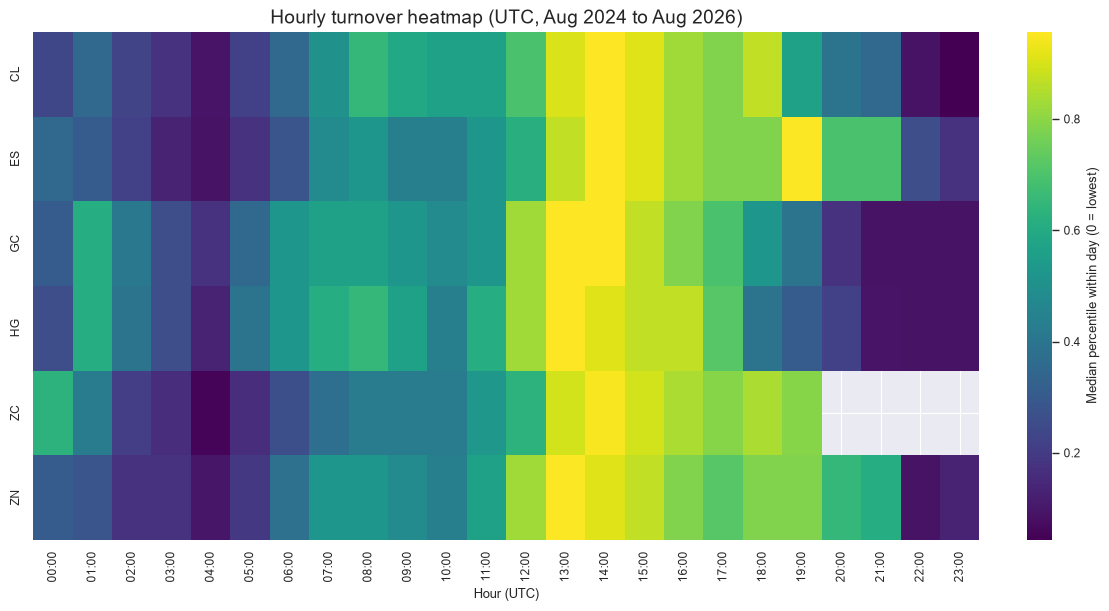

In [4]:
tables = agg.ranked(df)
fig = plots.heatmap(tables, "volume")

- Every contract peaks between 12:00 and 18:00 UTC, corresponding to the European afternoon overlapping the US morning.

- The overnight hours are the quietest across the board, with no contract breaking the pattern.

- Corn's blank cells after 19:00 reflect its shorter trading session rather than missing data.

### Hourly Absolute Return Profile
The heatmap below applies the same ranking to absolute return, isolating when price moves most rather than when volume arrives.

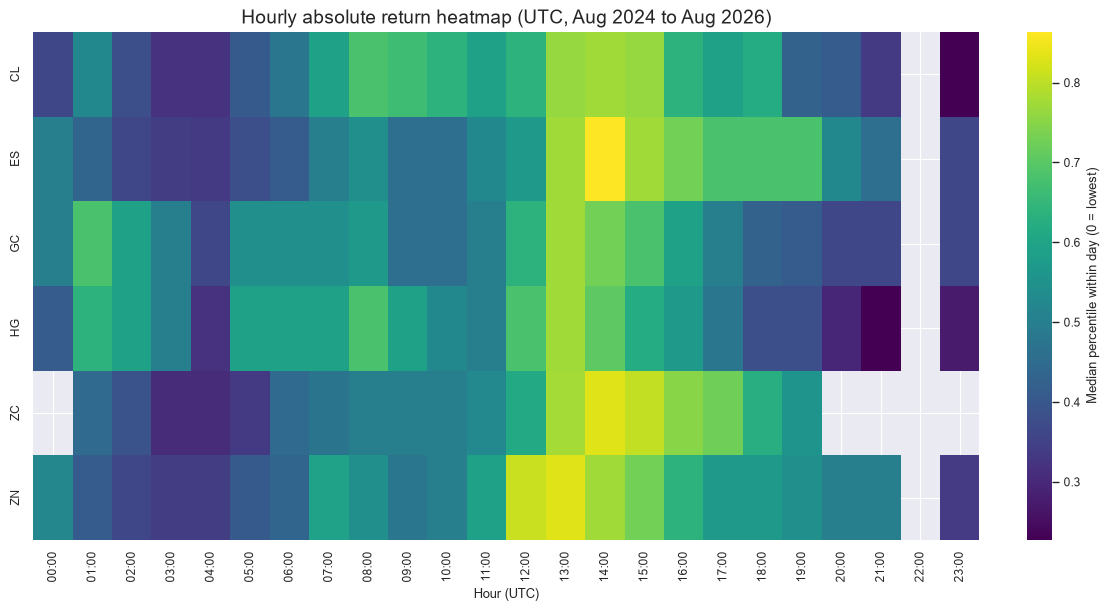

In [5]:
fig = plots.heatmap(tables, "rv")

- Absolute returns peak in a tighter window than turnover, around 13:00 to 15:00 UTC, coinciding with the US open and macroeconomic releases.

- Critically, they do not fall away overnight as sharply as volume does.

- That divergence between the two components is what the composite measure isolates.

### Hourly Amihud Illiquidity Profile
The heatmap below combines the two components into price movement per unit of flow, identifying the hours that are genuinely expensive to trade in.

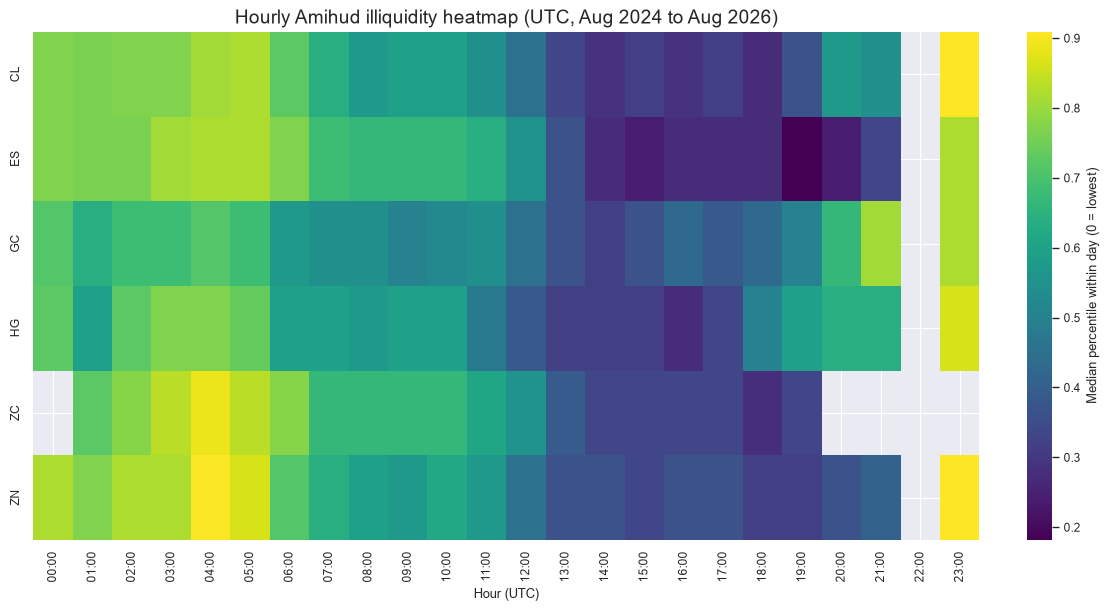

In [6]:
fig = plots.heatmap(tables, "amihud")

- The composite is not simply the inverse of turnover, which is why all three panels are shown.

- The worst hours are 00:00 to 06:00 UTC, where volume has fallen away but price movement has not, so each unit of flow pushes price further.

- 22:00 carries around 260 observations for turnover but only one for Amihud, since the maintenance break moves between 21:00 and 22:00 with the clocks, so the two hours a return needs rarely line up.

### Illiquidity Profile by Contract
The chart below plots median Amihud illiquidity through the day for each contract, with the interquartile range shaded to show day-to-day dispersion.

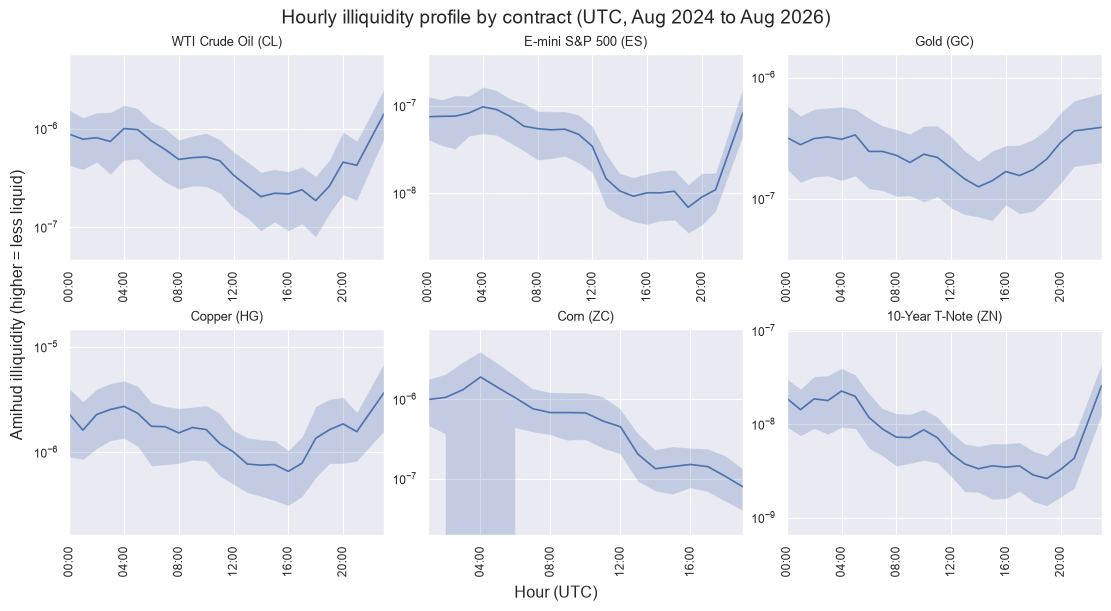

In [7]:
fig = plots.profiles(agg.profiles(df))

- Every contract shares the same broad shape, a trough through the US session and a peak overnight but the depth of that trough varies considerably.

- Gold is by some margin the flattest, while corn shows no trough at all, declining steadily from its overnight peak to its early close.

- The interquartile bands are wide relative to the movement in the medians, confirming this describes the typical day rather than forecasting any particular one.

### Normalised Profile Comparison
The chart below scales each contract to its own daily mean so the shapes can be compared directly, with the Asian, European and US sessions shaded and overlapping where more than one is open.

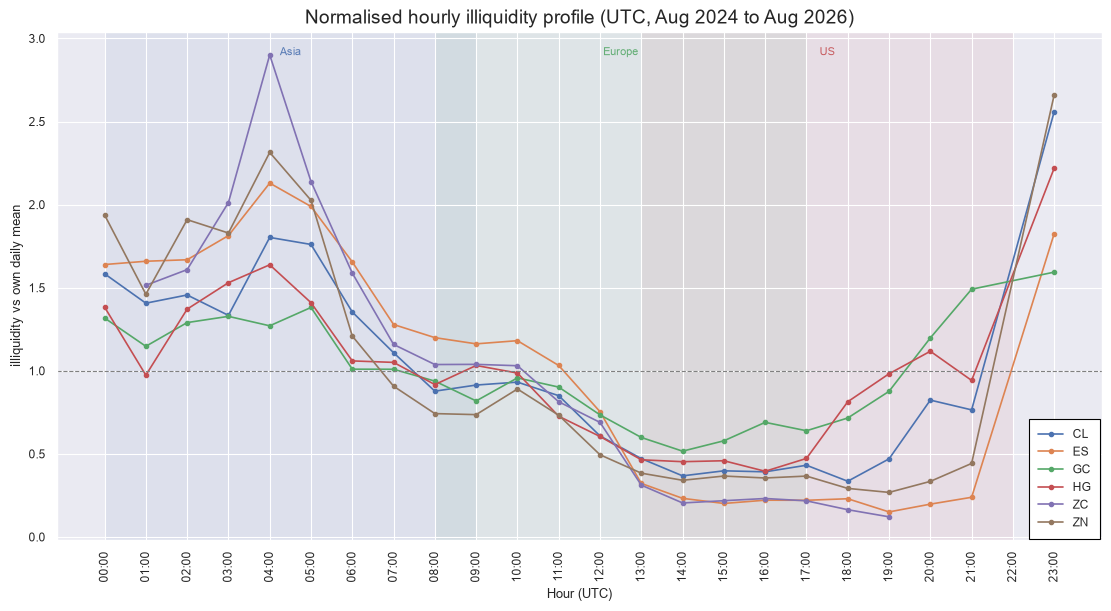

In [8]:
fig = plots.overlay(agg.overlay(df))

- Scaled this way the profiles are more alike than different, with all six troughing between 13:00 and 20:00 UTC and peaking between 23:00 and 05:00.

- Holding the exchange constant removes most of the variation in where the good execution window sits.

- Midnight sits squarely inside the expensive block, with every contract between 1.3 and 1.9 times its own daily mean at 00:00 and none falling below average until 08:00.

### Execution Timing Cost Summary
The table below aggregates the three cheapest and three dearest hours for each contract, alongside the ratio between the single worst hour and the single best.

In [9]:
agg.best_worst(df)

,cheapest hours (UTC),dearest hours (UTC),worst / best
instrument,,,
ZC,"19:00, 18:00, 14:00","04:00, 05:00, 03:00",23.9
ES,"19:00, 20:00, 15:00","04:00, 05:00, 23:00",14.1
ZN,"19:00, 18:00, 20:00","23:00, 04:00, 05:00",9.9
CL,"18:00, 14:00, 16:00","23:00, 04:00, 05:00",7.6
HG,"16:00, 14:00, 15:00","23:00, 04:00, 03:00",5.6
GC,"14:00, 15:00, 13:00","23:00, 21:00, 05:00",3.1


- The worst-to-best ratio runs from 3.1 for gold to 23.9 for corn, an eightfold spread across one exchange.

- The cheapest hours cluster in 13:00 to 20:00 UTC for all six, meaning the contracts agree on when to trade and differ only on how much it matters.

- The dearest are 23:00 and 03:00 to 05:00, corresponding to the reopen after the maintenance break and the hours before the Asian session becomes active.

### Stability Across Sub-periods
The table below splits the sample into two 12-month halves and recomputes the worst-to-best ratio for each, testing whether the ranking is a stable property of the contract or an artefact of the period.

In [10]:
first = df[df.date < pd.Timestamp("2025-08-05").date()]
second = df[df.date >= pd.Timestamp("2025-08-05").date()]

pd.concat({"year 1": agg.best_worst(first)["worst / best"],
           "year 2": agg.best_worst(second)["worst / best"]}, axis=1)

,year 1,year 2
instrument,,
ZC,18.9,17.4
ES,13.9,14.4
ZN,9.2,7.8
CL,5.5,5.1
HG,3.9,4.8
GC,2.5,3.1


- The ordering is identical across both halves, with no contract changing position.

- Magnitudes shift modestly, with corn easing from 18.9 to 17.4 and copper rising from 3.9 to 4.8 but the extremes remain more than five times apart in both periods.

- This supports treating the concentration of a contract's liquidity as a stable characteristic rather than a feature of the sample window.

### Conclusion

- This project evaluated intraday liquidity across six CME futures contracts over a 2-year period to test whether midnight UTC is a sensible default execution time.

- Midnight sits close to the worst hour of the day for every contract in the sample, meaning a system that computes and trades at the bar boundary is executing in the most expensive window by default rather than by choice.

- Deferring execution into the 13:00 to 20:00 UTC window moves the trade into conditions where price moves between three and twenty-four times less per unit of flow.

- The magnitude of that benefit depends entirely on the contract held, ranging from marginal for gold to substantial for corn.

- The ranking holds across both halves of the sample, so the concentration of a contract's liquidity appears to be a stable characteristic rather than a feature of the period.

### Potential Improvements

- Incorporate quote or order book data to convert the relative ranking into an absolute cost in basis points.

- Repeat the analysis in exchange local time to remove the daylight-saving smearing that blunts every session boundary in UTC.

- Extend the contract set beyond a single exchange to test whether the pattern holds for London and Asian listings.

- Attach the analysis to a live strategy to weigh the liquidity saving against the signal decay incurred by delaying execution.